Cechy z najwyższą wariancją (top 4):
- total sulfur dioxide: 1806.09
- free sulfur dioxide: 289.24
- residual sugar: 25.73
- alcohol: 1.51


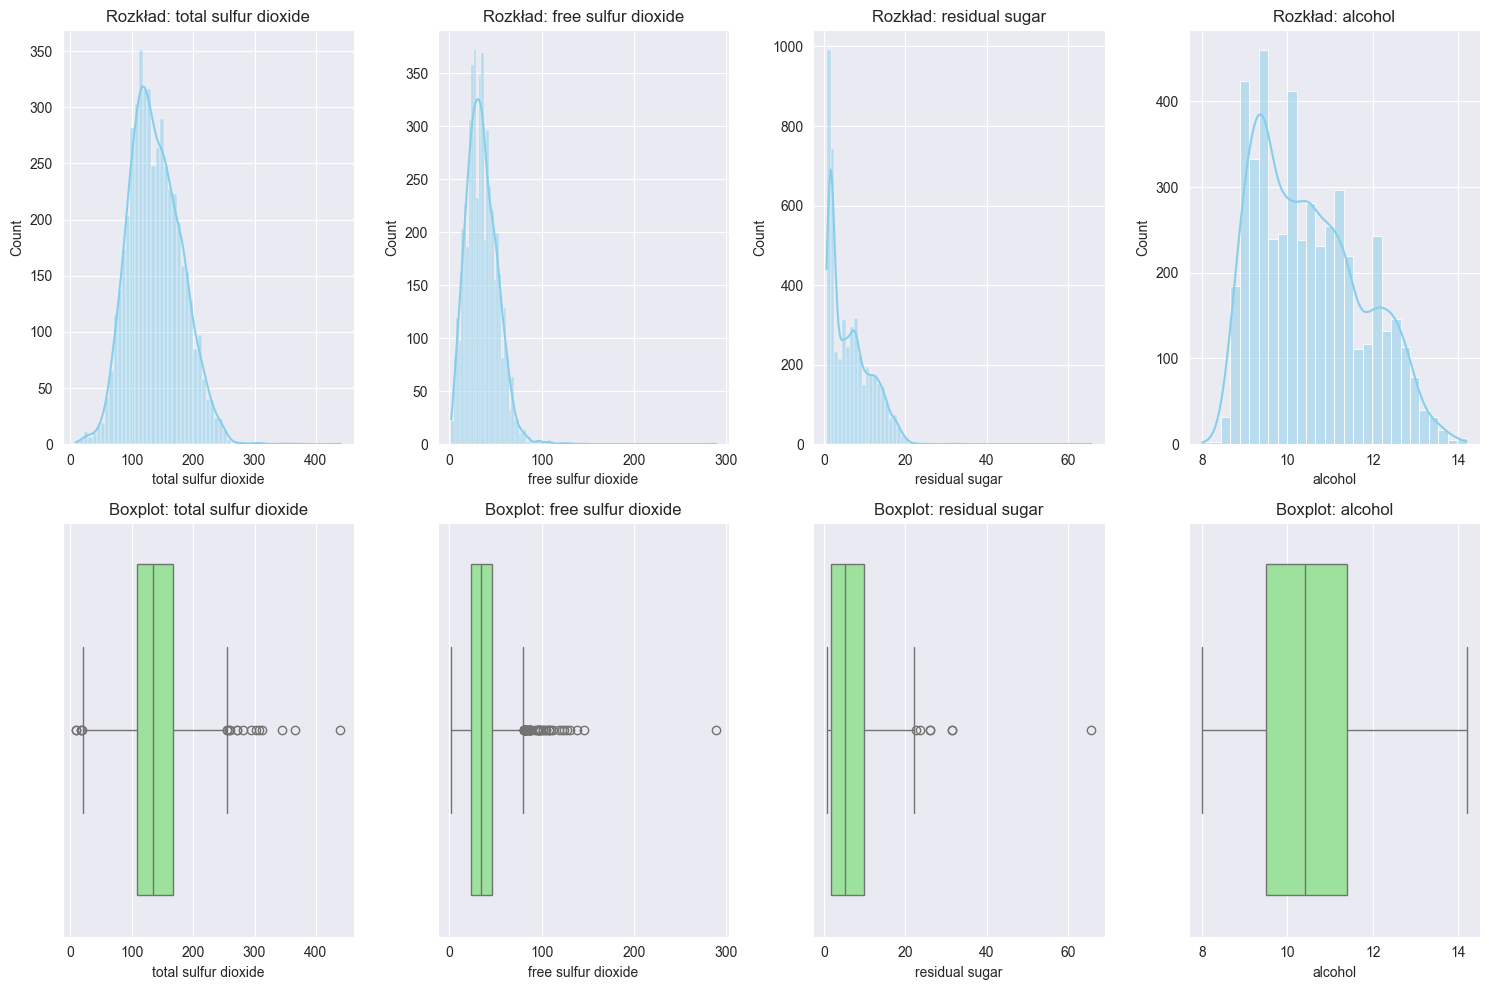

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Zadanie 1 ---
df_white = pd.read_csv('winequality-white.csv', sep=';')


variances = df_white.var().sort_values(ascending=False)

top_4_features = variances.head(4).index.tolist()

print("Cechy z najwyższą wariancją (top 4):")
for feat in top_4_features:
    print(f"- {feat}: {variances[feat]:.2f}")


plt.figure(figsize=(15, 10))

for i, feature in enumerate(top_4_features, 1):
    plt.subplot(2, 4, i)
    sns.histplot(df_white[feature], kde=True, color='skyblue')
    plt.title(f'Rozkład: {feature}')

    plt.subplot(2, 4, i + 4)
    sns.boxplot(x=df_white[feature], color='lightgreen')
    plt.title(f'Boxplot: {feature}')

plt.tight_layout()
plt.show()

In [7]:
import numpy as np

# --- Zadanie 2 ---
def detect_outlier_columns(df):

    outlier_cols = []
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        if not outliers.empty:
            outlier_cols.append(col)

    return outlier_cols

# --- TESTOWANIE FUNKCJI ---

cechy_z_odstajacymi = detect_outlier_columns(df_white)

print(f"Liczba cech z outlierami: {len(cechy_z_odstajacymi)}")
print("Lista tych cech:")
print(cechy_z_odstajacymi)

Liczba cech z outlierami: 11
Lista tych cech:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'quality']


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score

# --- Zadanie 3 ---
X = df_white.drop('quality', axis=1)
y = df_white['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scalers = {
    "Brak skalowania": None,
    "Standaryzacja (StandardScaler)": StandardScaler(),
    "Skalowanie Min-Max (MinMaxScaler)": MinMaxScaler(),
    "Skalowanie Robust (RobustScaler)": RobustScaler()
}

results = {}

print("--- Wyniki klasyfikacji (Accuracy) ---")

for name, scaler in scalers.items():
    X_tr_scaled, X_te_scaled = X_train.copy(), X_test.copy()

    if scaler:
        scaler.fit(X_tr_scaled)
        X_tr_scaled = scaler.transform(X_tr_scaled)
        X_te_scaled = scaler.transform(X_te_scaled)

    #model = LogisticRegression(max_iter=1000)
    #dane mają ogromne różnice w skali (np. jedna kolumna ma wartości rzędu 200, a druga 0.001)
    model = LogisticRegression(max_iter=5000)
    model.fit(X_tr_scaled, y_train)

    # Liczymy celność
    predictions = model.predict(X_te_scaled)
    acc = accuracy_score(y_test, predictions)

    results[name] = acc
    print(f"{name:35}: {acc:.4f}")

--- Wyniki klasyfikacji (Accuracy) ---


C:\Users\Kubuncio\PycharmProjects\Lab08_wpd\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Brak skalowania                    : 0.5374
Standaryzacja (StandardScaler)     : 0.5401
Skalowanie Min-Max (MinMaxScaler)  : 0.5361
Skalowanie Robust (RobustScaler)   : 0.5408


In [11]:
from sklearn.preprocessing import RobustScaler

# - Zadanie 4 ---
outlier_features = detect_outlier_columns(X_train)
print(f"Cechy zakwalifikowane do skalowania: {outlier_features}")

X_train_sel = X_train.copy()
X_test_sel = X_test.copy()

scaler = RobustScaler()

X_train_sel[outlier_features] = scaler.fit_transform(X_train_sel[outlier_features])
X_test_sel[outlier_features] = scaler.transform(X_test_sel[outlier_features])

model_sel = LogisticRegression(max_iter=5000)
model_sel.fit(X_train_sel, y_train)

acc_sel = accuracy_score(y_test, model_sel.predict(X_test_sel))
print(f"\nAccuracy (skalowanie selektywne): {acc_sel:.4f}")
print(f"Dla porównania (Brak skalowania z Zadania 3): {results['Brak skalowania']:.4f}")

# --- Odpowiedzi do zadania 4 ---

#Czy sam fakt występowania wartości odstających jest wskazówką do przeprowadzenia skalowania danych?
#Tak, ponieważ wartości odstające sztucznie zwiększają wariancję i zakresy cech.

#Czy obecność wartości odstających może być czynnikiem decyzyjnym w kontekście zastosowania konkretnej metody skalowania danych?
#Zdecydowanie tak.

#Jaki inny czynnik występujący w danych może kwalifikować cechę do poddania jej skalowaniu?
#Głównym czynnikiem są różne rzędy wielkości (skale) cech. Nawet jeśli dane nie mają outlierów, ale jedna cecha ma zakres [0, 1], (np. density), a druga [0, 500] (np. total sulfur dioxide), to bez skalowania model uzna tę drugą za setki razy ważniejszą

Cechy zakwalifikowane do skalowania: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates']

Accuracy (skalowanie selektywne): 0.5388
Dla porównania (Brak skalowania z Zadania 3): 0.5374
